In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_pickle('../data/raw/LSWMD.pkl')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
df.head(3)

Shape: (811457, 6)

Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Dtypes:
 waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


In [4]:
print("=== Dataset Overview ===")
print(f"Total wafers: {len(df):,}")

def extract_label(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:          # empty array → treat as unlabeled
            return None
        return x.flat[0]         # safely grab first element regardless of nesting
    elif x is None:
        return None
    elif isinstance(x, float) and np.isnan(x):
        return None
    return x

df['label_clean'] = df['failureType'].apply(extract_label)

print(f"Labeled wafers:   {df['label_clean'].notna().sum():,}")
print(f"Unlabeled wafers: {df['label_clean'].isna().sum():,}")
print(f"Label rate:       {df['label_clean'].notna().mean()*100:.1f}%")
print(f"\nClass counts:\n{df['label_clean'].value_counts(dropna=False)}")

=== Dataset Overview ===
Total wafers: 811,457
Labeled wafers:   172,950
Unlabeled wafers: 638,507
Label rate:       21.3%

Class counts:
label_clean
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


This is really useful — here's what jumps out:
Key observations:

* Only 21.3% of wafers are labeled — the rest we'll ignore for supervised learning
* none (147K) dominates the labeled set — these are defect-free wafers
* Real defect classes are tiny: Donut (555), Near-full (149), Scratch (1,193)
* Imbalance ratio is roughly 990:1 (none vs Near-full) — this is severe and will be a core challenge

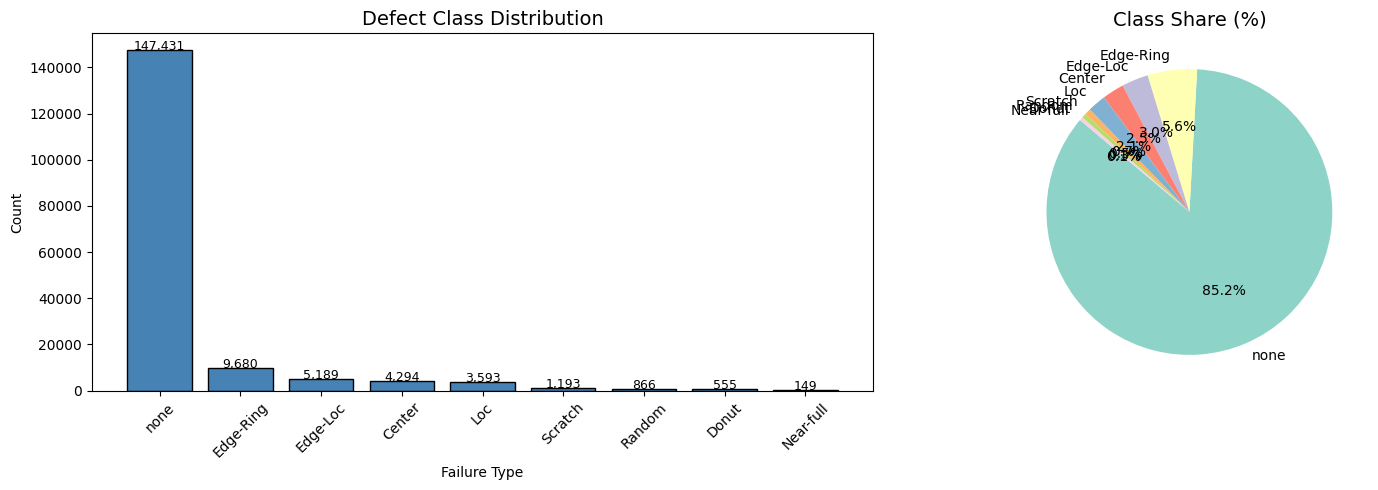


Class imbalance ratio (max/min): 989.5


In [5]:
labeled = df[df['label_clean'].notna()].copy()
labeled['failureType'] = labeled['label_clean']
counts = labeled['failureType'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Defect Class Distribution', fontsize=14)
axes[0].set_xlabel('Failure Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set3.colors)
axes[1].set_title('Class Share (%)', fontsize=14)

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150)
plt.show()

print("\nClass imbalance ratio (max/min):", round(counts.max() / counts.min(), 1))

Perfect — that chart tells the whole story. none is 85.2% of the data, and Near-full is just 0.1%. This imbalance is exactly why we'll need focal loss and weighted sampling later.

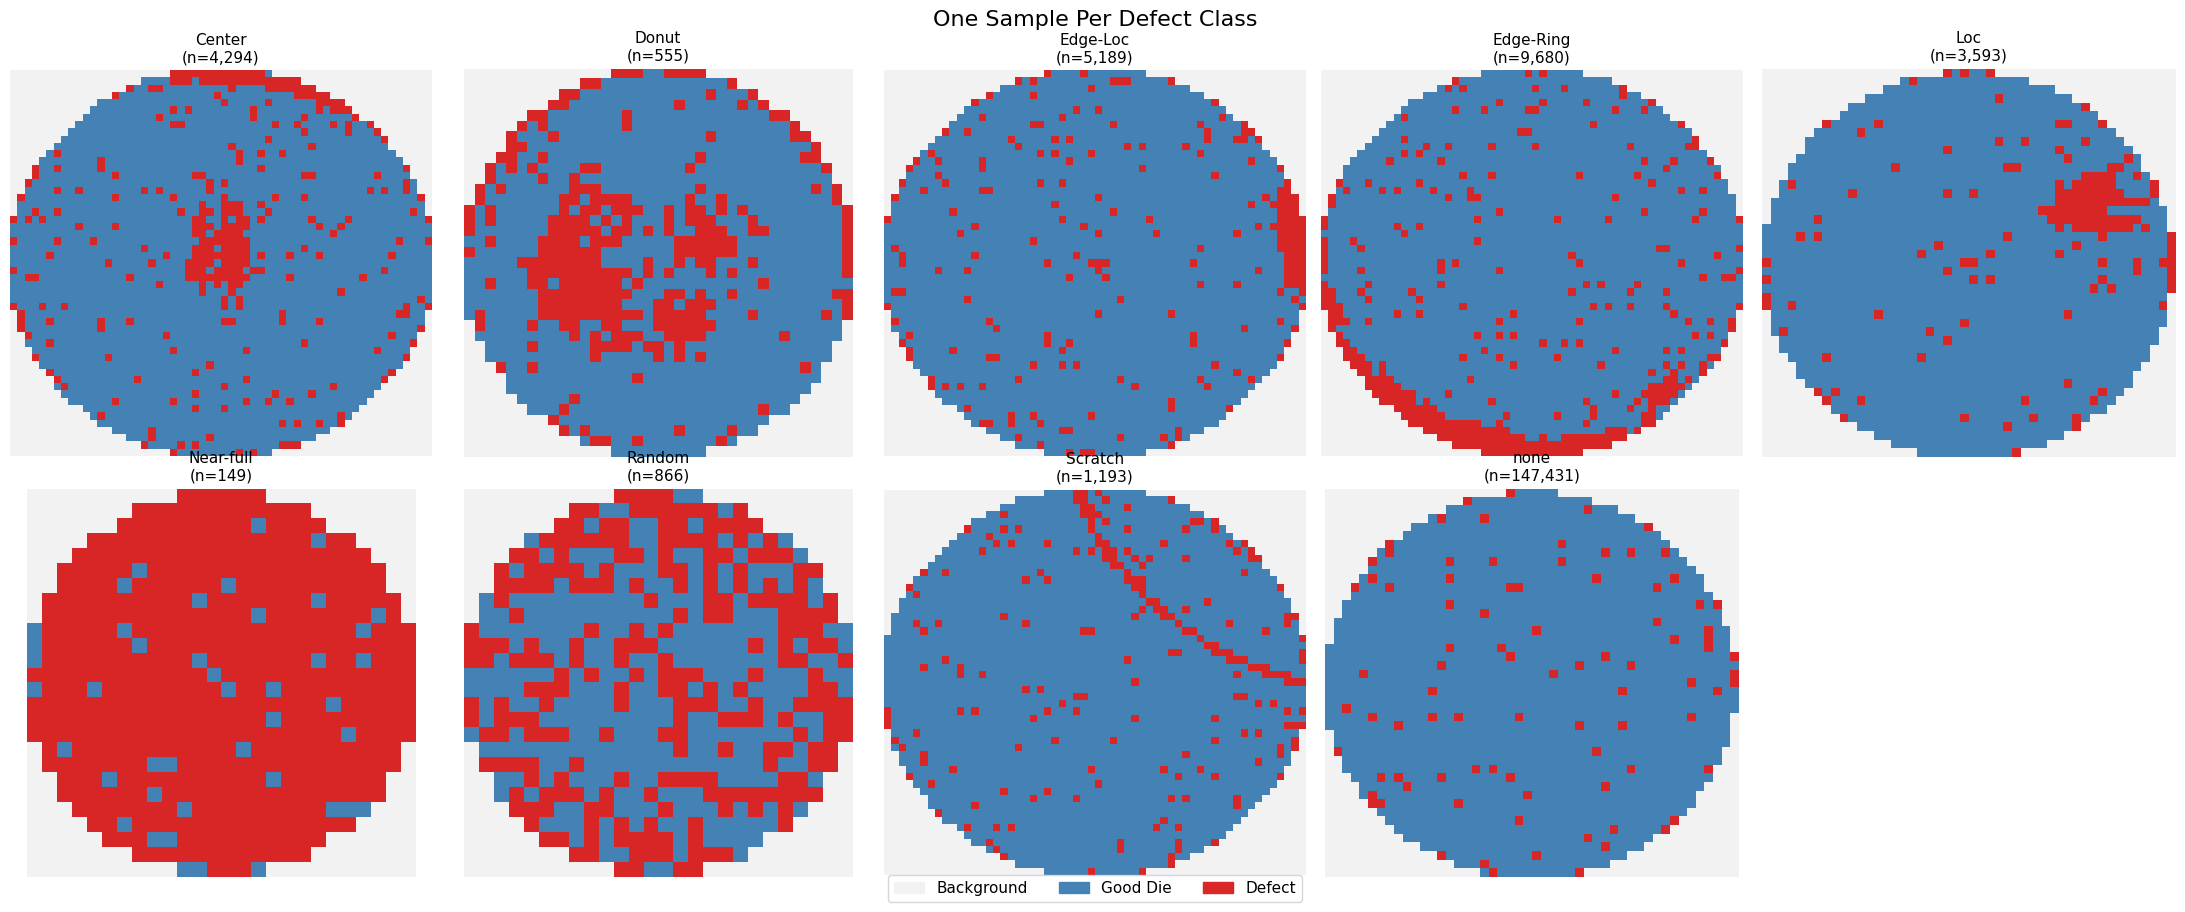

In [6]:
failure_types = sorted(labeled['failureType'].unique())
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, ftype in enumerate(failure_types):
    sample = labeled[labeled['failureType'] == ftype].iloc[0]
    wafer = sample['waferMap']
    
    colored = np.zeros((*wafer.shape, 3))
    colored[wafer == 0] = [0.95, 0.95, 0.95]
    colored[wafer == 1] = [0.27, 0.51, 0.71]
    colored[wafer == 2] = [0.85, 0.15, 0.15]
    
    axes[idx].imshow(colored, interpolation='nearest')
    axes[idx].set_title(f'{ftype}\n(n={counts[ftype]:,})', fontsize=11)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(failure_types), len(axes)):
    axes[idx].set_visible(False)

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color=(0.95, 0.95, 0.95), label='Background'),
    mpatches.Patch(color=(0.27, 0.51, 0.71), label='Good Die'),
    mpatches.Patch(color=(0.85, 0.15, 0.15), label='Defect'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('One Sample Per Defect Class', fontsize=16)
plt.tight_layout()
plt.savefig('../data/processed/sample_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

This looks fantastic! The spatial signatures are very distinct — exactly what a CNN will pick up on:

* Scratch — clear diagonal line pattern
* Edge-Ring — red ring around the entire perimeter
* Donut — red cluster in the middle ring
* Near-full — almost entirely red (catastrophic wafer)
* Center — red concentrated in the middle
* Loc/Edge-Loc — localized blob on one side
* Random — scattered with no pattern (hardest to learn)
* none — sparse random red dots (normal noise)

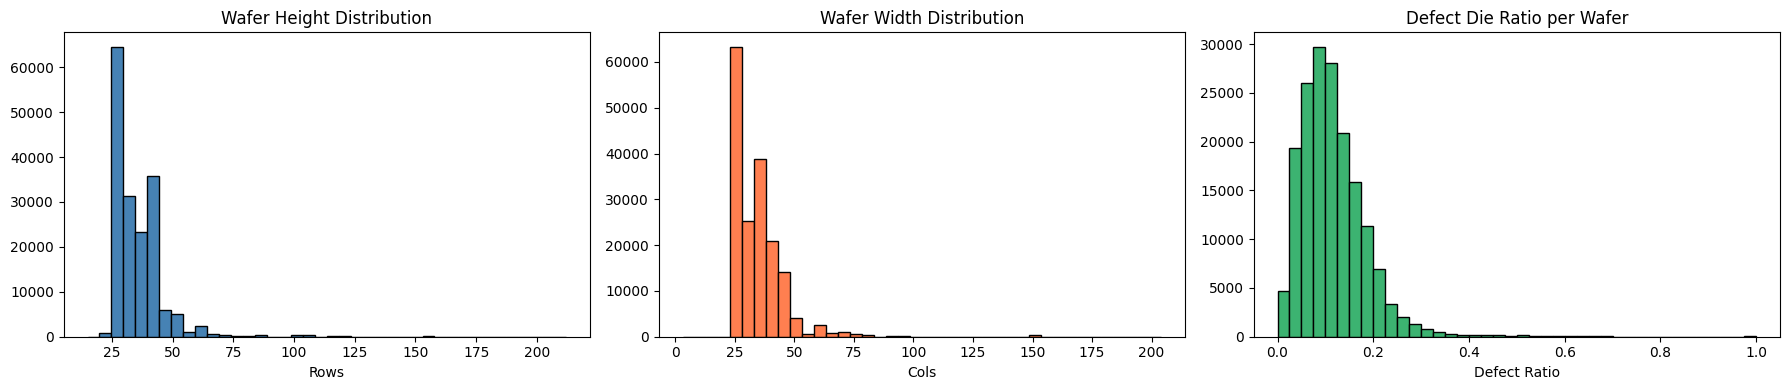

       wafer_rows  wafer_cols  wafer_area  defect_ratio
count   172950.00   172950.00   172950.00     172950.00
mean        35.23       34.82     1344.81          0.12
std         11.10       11.88     1310.10          0.07
min         15.00        3.00       45.00          0.00
25%         27.00       27.00      676.00          0.07
50%         33.00       33.00     1020.00          0.11
75%         41.00       40.00     1596.00          0.15
max        212.00      204.00    28611.00          1.00


In [7]:
labeled['wafer_rows'] = labeled['waferMap'].apply(lambda x: x.shape[0])
labeled['wafer_cols'] = labeled['waferMap'].apply(lambda x: x.shape[1])
labeled['wafer_area'] = labeled['wafer_rows'] * labeled['wafer_cols']
labeled['defect_ratio'] = labeled['waferMap'].apply(
    lambda x: (x == 2).sum() / max((x > 0).sum(), 1)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(labeled['wafer_rows'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Wafer Height Distribution')
axes[0].set_xlabel('Rows')

axes[1].hist(labeled['wafer_cols'], bins=40, color='coral', edgecolor='black')
axes[1].set_title('Wafer Width Distribution')
axes[1].set_xlabel('Cols')

axes[2].hist(labeled['defect_ratio'], bins=40, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Defect Die Ratio per Wafer')
axes[2].set_xlabel('Defect Ratio')

plt.tight_layout()
plt.savefig('../data/processed/size_distribution.png', dpi=150)
plt.show()

print(labeled[['wafer_rows','wafer_cols','wafer_area','defect_ratio']].describe().round(2))

Great data — here's what matters for preprocessing:

* Most wafers are 25–50px in size, median ~33×33
* Outliers go up to 212×204 — we'll cap and resize to 64×64
* Average defect ratio is 12% — confirms most of the wafer is healthy even in defective samples
* Min cols = 3 — some wafers are tiny and nearly useless, we may filter those later

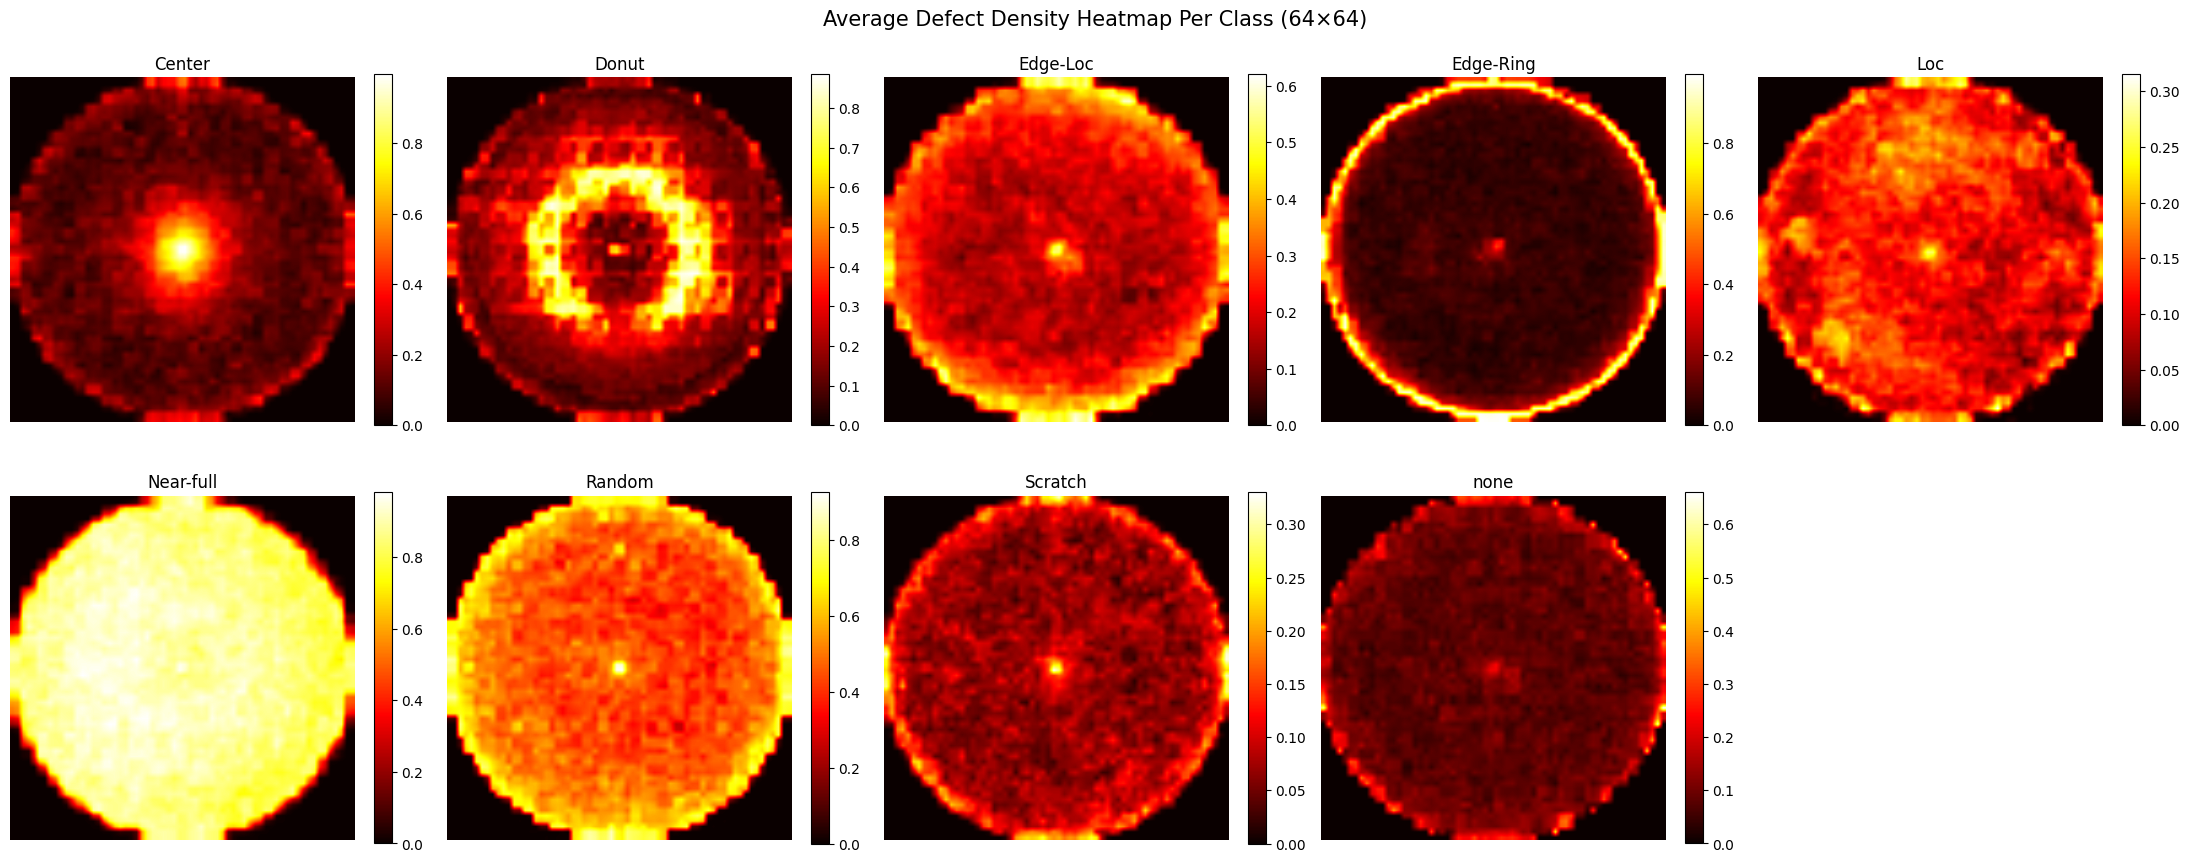

In [8]:
from PIL import Image

TARGET_SIZE = 64

def resize_wafer(wafer, size=TARGET_SIZE):
    img = Image.fromarray(wafer.astype(np.uint8))
    return np.array(img.resize((size, size), Image.NEAREST))

failure_types = sorted(labeled['failureType'].unique())
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, ftype in enumerate(failure_types):
    samples = labeled[labeled['failureType'] == ftype]['waferMap'].values[:200]
    maps = np.array([resize_wafer(w) for w in samples])
    defect_density = (maps == 2).mean(axis=0)
    
    im = axes[idx].imshow(defect_density, cmap='hot', interpolation='bilinear')
    axes[idx].set_title(f'{ftype}', fontsize=12)
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

# Hide unused subplots
for idx in range(len(failure_types), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Average Defect Density Heatmap Per Class (64×64)', fontsize=15)
plt.tight_layout()
plt.savefig('../data/processed/defect_heatmaps.png', dpi=150)
plt.show()

These heatmaps are excellent — the CNN is going to have a very easy time with most classes. Here's what they confirm:

* Center — bright hot spot dead center, very consistent ✅
* Donut — perfect ring signature, most distinct pattern in the dataset ✅
* Edge-Ring — crisp bright ring at the perimeter ✅
* Near-full — uniformly bright, entire wafer affected ✅
* Scratch — surprisingly diffuse when averaged — individual scratches go in different directions, so they wash out. This will be the hardest class for the CNN
* Random vs none — these look very similar in density, which means the model may confuse them
Loc/Edge-Loc — low density but spatially biased, should be learnable

In [9]:
# Drop tiny wafers that are likely corrupt (min cols was 3)
labeled = labeled[labeled['wafer_cols'] >= 10].copy()

# Save for use in all future steps
labeled.to_pickle('../data/processed/labeled_wafers.pkl')

print(f"Saved {len(labeled):,} labeled wafers to data/processed/labeled_wafers.pkl")
print(f"\nFinal class counts:")
print(labeled['failureType'].value_counts())
print(f"\nMin wafer size after filtering: {labeled['wafer_rows'].min()} x {labeled['wafer_cols'].min()}")
print(f"Max wafer size after filtering: {labeled['wafer_rows'].max()} x {labeled['wafer_cols'].max()}")

Saved 172,948 labeled wafers to data/processed/labeled_wafers.pkl

Final class counts:
failureType
none         147429
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Min wafer size after filtering: 18 x 13
Max wafer size after filtering: 212 x 204


EDA Summary for your portfolio/README:

* 172,948 labeled wafers across 9 classes
* Severe imbalance: 85.2% none, down to 0.09% Near-full
* Wafer sizes range 18×13 to 212×204 → all will be resized to 64×64
* Most learnable: Donut, Edge-Ring, Center, Near-full
* Hardest: Scratch, Random vs none confusion

